In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import HTML, display

# from core.config_loader import MIN_BIN, MAX_BIN, MIN_BIN_SIZE, MAX_BIN_SIZE, MIN_DIFF_WOE, SPECIAL
from core.woe_stats import create_woe_df, get_bin_stats, special_mask
# from woe_all.optimization import calculate_feature
from woe_all.plotting import plot_options
from woe_all.html_tables import display_woe_tables
from optbinning import OptimalBinning

%matplotlib inline


In [2]:
MIN_BIN = 4
MAX_BIN = 10
MIN_BIN_SIZE = 0.05
MAX_BIN_SIZE = 0.5
MIN_DIFF_WOE = 0.01
SPECIAL = ['MISSING', 0, 'SME']


## Hàm hỗ trợ

In [3]:
OPTIONS = {
    "1. Free optimization": "auto",
    "2. Monotonic": "auto_asc_desc",
    "3. U-shape / heuristic": "auto_heuristic",
}

In [4]:
class _InfeasibleModel:
    def __init__(self):
        self.status = "INFEASIBLE"
        self.splits = []
        self.binning_table = None


def calculate_feature(feature, X_train, y, considerSPECIAL=False):
    x_original = X_train[feature].copy()

    special_values = list(SPECIAL)
    if considerSPECIAL:
        mask = ~special_mask(x_original, special=special_values)
        x = x_original.loc[mask]
        y_clean = y.loc[mask]
        display_x = x_original
        display_y = y
        feature_special = special_values
    else:
        mask = ~special_mask(x_original, special=special_values)
        x = x_original.loc[mask]
        y_clean = y.loc[mask]
        display_x = x
        display_y = y_clean
        feature_special = []

    n_old = len(X_train)
    n_new = len(x)

    if n_new == 0:
        raise ValueError("Feature has no usable observations.")

    if considerSPECIAL:
        min_bin_size = MIN_BIN_SIZE * n_old / n_new
        max_bin_size = min(MAX_BIN_SIZE * n_old / n_new, 1)
    else:
        min_bin_size = MIN_BIN_SIZE
        max_bin_size = MAX_BIN_SIZE

    infeasible = considerSPECIAL and min_bin_size > 0.5

    p_bar = np.mean(y_clean)
    min_event_rate_diff = 2 * p_bar * (1 - p_bar) * np.tanh(MIN_DIFF_WOE / 2)

    part = "considerSPECIAL" if considerSPECIAL else "removeSPECIAL"

    results = {}

    for option_name, trend in OPTIONS.items():
        if infeasible:
            optb = _InfeasibleModel()
        else:
            optb = OptimalBinning(name=feature, dtype="numerical", min_n_bins=MIN_BIN, max_n_bins=MAX_BIN, min_bin_size=min_bin_size, max_bin_size=max_bin_size, min_event_rate_diff=min_event_rate_diff, monotonic_trend=trend)
            optb.fit(x, y_clean)

        missing_first = considerSPECIAL and optb.status == "OPTIMAL"

        results[f"{part} | {option_name}"] = {
            "part": part,
            "option": option_name,
            "model": optb,
            "splits": optb.splits,
            "binning_table": optb.binning_table,
            "x": display_x,
            "y": display_y,
            "missing_first": missing_first,
            "special": feature_special,
        }

    return results


In [5]:
def validate_splits(x, splits, min_n_bins, max_n_bins, min_bin_size, max_bin_size, missing_first=False, special=None):
    """
    Validate manually edited split points.
    """

    splits = np.array(splits, dtype=float)

    # Check finite
    if not np.all(np.isfinite(splits)):
        return {'valid': False, 'message': 'Edited splits phải là các số finite.'}
    # Sort
    splits = np.sort(splits)
    # Check duplicate
    if len(np.unique(splits)) != len(splits):
        return {'valid': False, 'message': 'Edited splits chứa duplicate split point.'}

    n_bins = len(splits) + 1

    if n_bins < min_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, nhỏ hơn min_n_bins = '
                f'{min_n_bins}.'
            )
        }

    if n_bins > max_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, lớn hơn max_n_bins = '
                f'{max_n_bins}.'
            )
        }

    bin_stats = get_bin_stats(
        x=x,
        y=pd.Series(index=x.index, data=0),
        splits=splits,
        missing_first=missing_first,
        special=special,
    )

    numeric_stats = bin_stats[~bin_stats['bin'].astype(str).str.startswith(('Missing', 'Special'))].copy()
    min_violation = numeric_stats[numeric_stats['prob_n_obs'] < min_bin_size].copy()
    max_violation = numeric_stats[numeric_stats['prob_n_obs'] > max_bin_size].copy()

    valid = (len(min_violation) == 0 and len(max_violation) == 0)

    return {
        'valid': valid,
        'n_bins': n_bins,
        'splits': splits,
        'bin_stats': bin_stats,
        'min_violation': min_violation,
        'max_violation': max_violation,
        'message': (
            'Edited splits hợp lệ.' if valid else 'Edited splits vi phạm bin-size constraint.'
        )
    }


In [6]:
def plot_raw_woe(x, y, feature='', n_bins=50, special=None, smoothing=0.5, splits_ref=None):
    data = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'), 'target': y}).copy()
    data = data[data['target'].isin([0, 1])].copy()
    if data.empty:
        return

    missing = data['x'].isna()
    special_values = [v for v in (special or []) if v != 'MISSING']
    special = pd.Series(False, index=data.index)
    for v in special_values:
        special = special | data['x'].eq(v)
    numeric = ~(missing | special)
    x_numeric = data.loc[numeric, 'x']

    n_unique_num = x_numeric.nunique()

    if n_unique_num == 0:
        numeric_bins = pd.Series(pd.NA, index=data.index, dtype='object')
        bin_labels = []
    elif n_unique_num <= n_bins:
        values = np.sort(x_numeric.unique())
        numeric_bins = data['x'].map({v: str(v) for v in values}).where(numeric)
        bin_labels = [str(v) for v in values]
    else:
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(x_numeric.quantile(quantiles).to_numpy())
        if len(edges) < 2:
            numeric_bins = data['x'].map({x_numeric.iloc[0]: str(x_numeric.iloc[0])}).where(numeric)
            bin_labels = [str(x_numeric.iloc[0])]
        else:
            numeric_bins = pd.cut(data['x'], bins=edges, include_lowest=True, right=True)
            bin_labels = [str(v) for v in numeric_bins.dropna().unique()]
            bin_labels = sorted(bin_labels, key=lambda z: float(z.split(',')[0].strip('([')))

    data['_bin_'] = numeric_bins.astype(object)
    data.loc[missing, '_bin_'] = 'MISSING'
    data.loc[special, '_bin_'] = 'SPECIAL'

    grouped = data.groupby('_bin_', dropna=False)['target'].agg(
        n_obs='count',
        n_card='sum'
    ).reset_index()

    grouped['n_non_card'] = grouped['n_obs'] - grouped['n_card']

    total_card = grouped['n_card'].sum()
    total_non_card = grouped['n_non_card'].sum()
    n_categories = len(grouped)

    grouped['pct_card'] = grouped['n_card'] / total_card if total_card > 0 else 0
    grouped['pct_non_card'] = grouped['n_non_card'] / total_non_card if total_non_card > 0 else 0

    grouped['pct_card_smooth'] = (grouped['n_card'] + smoothing) / (total_card + smoothing * n_categories)
    grouped['pct_non_card_smooth'] = (grouped['n_non_card'] + smoothing) / (total_non_card + smoothing * n_categories)
    grouped['WOE'] = np.log(grouped['pct_card_smooth'] / grouped['pct_non_card_smooth'])
    grouped['pct_obs'] = grouped['n_obs'] / len(data)

    def sort_key(value):
        if value == 'MISSING':
            return (-2, 0.0)
        if value == 'SPECIAL':
            return (-1, 0.0)
        try:
            if isinstance(value, str) and value.startswith(('(', '[')):
                left = value.split(',')[0].strip('([')
                return (0, float(left))
            return (0, float(value))
        except (ValueError, TypeError):
            return (1, 0.0)

    grouped['_sort'] = grouped['_bin_'].apply(sort_key)
    grouped = grouped.sort_values('_sort').reset_index(drop=True).drop(columns='_sort')

    x_pos = np.arange(len(grouped))
    labels = grouped['_bin_'].astype(str).tolist()
    missing_mask = grouped['_bin_'].eq('MISSING')
    special_mask = grouped['_bin_'].eq('SPECIAL')

    fig, ax_woe = plt.subplots(figsize=(15, 6))
    ax_obs = ax_woe.twinx()

    ax_obs.bar(x_pos, grouped['pct_obs'], width=0.85, color='#5B9BD5', alpha=0.28, label='% Obs', zorder=1)
    ax_woe.plot(x_pos, grouped['WOE'], color='green', marker='o', markersize=4, linewidth=1.3, linestyle='--', label='WOE', zorder=3)

    if missing_mask.any():
        ax_woe.scatter(x_pos[missing_mask], grouped.loc[missing_mask, 'WOE'], color='red', s=45, zorder=4)

    if special_mask.any():
        ax_woe.scatter(x_pos[special_mask], grouped.loc[special_mask, 'WOE'], color='orange', s=45, zorder=4)

    ax_woe.axhline(0, color='red', linestyle=':', linewidth=1)
    ax_woe.set_ylabel('WOE', color='green')
    ax_woe.tick_params(axis='y', labelcolor='green')
    ax_obs.set_ylabel('% Observations', color='#5B9BD5')
    ax_obs.tick_params(axis='y', labelcolor='#5B9BD5')
    ax_obs.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

    if splits_ref is not None and n_unique_num > n_bins and len(x_numeric) > 0:
        for split in splits_ref:
            if x_numeric.min() < split < x_numeric.max():
                idx = np.searchsorted(x_numeric.quantile(np.linspace(0, 1, n_bins + 1)).to_numpy(), split, side='right') - 1
                idx = max(0, min(idx, len(x_pos) - 1))
                ax_woe.axvline(idx, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

    ax_woe.set_xticks(x_pos)
    ax_woe.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax_woe.set_xlabel(feature)
    ax_woe.set_title(f'Weight of Evidence by {feature} (n_categories={len(grouped)})')
    ax_woe.grid(axis='y', alpha=0.15)

    handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
    handles_obs, labels_obs = ax_obs.get_legend_handles_labels()
    ax_woe.legend(handles_woe + handles_obs, labels_woe + labels_obs, loc='upper left')

    plt.tight_layout()
    plt.show()


In [7]:
def plot_woe_onsplits(df, x, y, splits, feature='', missing_first=False, special=None, ax=None):
    bin_stats = get_bin_stats(x=x, y=y, splits=splits, missing_first=missing_first, special=special)

    # Nếu truyền ax từ ngoài vào thì vẽ lên ax đó, ngược lại mới tạo fig/ax mới
    if ax is None:
        fig, ax_woe = plt.subplots(figsize=(7, 4))
    else:
        ax_woe = ax
        fig = ax_woe.get_figure()

    x_pos = np.arange(len(df))

    ax_woe.plot(x_pos, df['WOE'], marker='o', linewidth=2, label='WOE')
    ax_woe.axhline(0, linestyle='--', linewidth=1)

    ax_woe.set_xlabel('Bin')
    ax_woe.set_ylabel('WOE')
    ax_woe.set_xticks(x_pos)
    ax_woe.set_xticklabels(df['Bin'], rotation=30, ha='right')
    ax_woe.grid(axis='y', alpha=0.3)

    ax_count = ax_woe.twinx()
    ax_count.bar(x_pos, bin_stats['n_obs'], alpha=0.25, width=0.6, label='Bin Count')

    ax_count.set_ylabel('Bin Count')
    ax_woe.set_title(f'{feature}')

    handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
    handles_count, labels_count = ax_count.get_legend_handles_labels()

    ax_woe.legend(handles_woe + handles_count, labels_woe + labels_count, loc='best')

    return fig


In [8]:


def _woe_trend(woe):
    woe = pd.to_numeric(woe, errors='coerce').dropna().to_numpy()

    if len(woe) < 3:
        return 'no_clear_trend'

    diff = np.diff(woe)
    diff = diff[diff != 0]

    if len(diff) == 0:
        return 'no_clear_trend'

    signs = np.sign(diff)

    if np.all(signs > 0) or np.all(signs < 0):
        return 'monotonic'

    changes = np.where(signs[1:] != signs[:-1])[0]

    if len(changes) == 1:
        i = changes[0]

        if signs[i] < 0 and signs[i + 1] > 0:
            return 'u_shape'

        if signs[i] > 0 and signs[i + 1] < 0:
            return 'inverted_u_shape'

    return 'no_clear_trend'


def compare_woe_tables(old_df,new_df,thresholds=(0.5,0.3,0.1,0.02)):
    old = old_df.copy().reset_index(drop=True)
    new = new_df.copy().reset_index(drop=True)

    old_iv_total = old['IV_total'].iloc[0]
    new_iv_total = new['IV_total'].iloc[0]
    iv_total_gap = new_iv_total - old_iv_total

    if iv_total_gap > 0:
        iv_total_direction = 'increased'
    elif iv_total_gap < 0:
        iv_total_direction = 'decreased'
    else:
        iv_total_direction = 'unchanged'

    old_trend = _woe_trend(old['WOE'])
    new_trend = _woe_trend(new['WOE'])

    trend_summary = pd.DataFrame({
        'table': ['old', 'edit'],
        'WOE_trend': [old_trend, new_trend]
    })

    if len(old) != len(new):
        raise ValueError(
            f'Old and edit must have the same number of bins: '
            f'old={len(old)}, edit={len(new)}'
        )

    iv_comparison = pd.DataFrame({
        'bin_order': np.arange(1,len(old) + 1),
        'Bin_old': old['Bin'],
        'Bin_new': new['Bin'],
        'IV_old': old['IV_detail'],
        'IV_new': new['IV_detail']
    })

    iv_comparison['gap'] = iv_comparison['IV_new'] - iv_comparison['IV_old']
    # iv_comparison['abs_gap'] = iv_comparison['gap'].abs()

    def _get_threshold_range(iv, thresholds):
        """
        Xác định khoảng threshold mà IV thuộc vào.

        thresholds được hiểu là các mốc giảm dần, ví dụ:
        (0.5, 0.3, 0.1, 0.02)
        """

        thresholds = sorted(thresholds, reverse=True)

        for i, threshold in enumerate(thresholds):
            if iv >= threshold:
                if i == 0:
                    return f">= {threshold:.2f}"
                else:
                    upper = thresholds[i - 1]
                    return f"[{threshold:.2f}, {upper:.2f})"

        return f"< {thresholds[-1]:.2f}"


    threshold_changes = []

    for _, row in iv_comparison.iterrows():

        old_iv = row['IV_old']
        new_iv = row['IV_new']

        old_range = _get_threshold_range(old_iv, thresholds)
        new_range = _get_threshold_range(new_iv, thresholds)

        threshold_changed = old_range != new_range

        threshold_changes.append({
            'bin_order': row['bin_order'],
            'Bin_old': row['Bin_old'],
            'Bin_new': row['Bin_new'],
            'IV_old': old_iv,
            'IV_new': new_iv,
            'gap': row['gap'],
            'threshold_old': old_range,
            'threshold_new': new_range,
            'threshold_changed': threshold_changed
        })

    threshold_changes = pd.DataFrame(threshold_changes)

    return {
        'iv_total': {
            'old': old_iv_total,
            'edit': new_iv_total,
            'gap': iv_total_gap,
            'abs_gap': abs(iv_total_gap),
            'direction': iv_total_direction
        },
        'woe_trend': trend_summary,
        'iv_bin_comparison': iv_comparison,
        'threshold_changes': threshold_changes
    }

In [9]:
def check_valid_bins(validation, min_bin_size, max_bin_size, min_n_bins, max_n_bins):
    if not validation['valid']:
        print("Result: Edited splits không hợp lệ.")

        if validation.get('n_bins', 0) < min_n_bins:
            print(f"- Số bin = {validation['n_bins']}, nhỏ hơn min_n_bins = {min_n_bins}.")
        elif validation.get('n_bins', 0) > max_n_bins:
            print(f"- Số bin = {validation['n_bins']}, lớn hơn max_n_bins = {max_n_bins}.")

        min_violation = validation.get('min_violation', pd.DataFrame())
        if not min_violation.empty:
            print(f"- Các bin có prob_n_obs < min_bin_size ({min_bin_size:.2%}):")
            display(min_violation.style.format({'prob_n_obs': '{:.2%}'}))

        max_violation = validation.get('max_violation', pd.DataFrame())
        if not max_violation.empty:
            print(f"- Các bin có prob_n_obs > max_bin_size ({max_bin_size:.2%}):")
            display(max_violation.style.format({'prob_n_obs': '{:.2%}'}))

        raise ValueError("Hãy chỉnh lại edited_splits.")


In [10]:
def comment_woe_trend(trend):
    old_trend = trend.loc[trend['table'] == 'old', 'WOE_trend'].iloc[0]
    edit_trend = trend.loc[trend['table'] == 'edit', 'WOE_trend'].iloc[0]

    print(f"WOE trend gốc : {old_trend}")
    print(f"WOE trend mới : {edit_trend}")

    if old_trend == edit_trend:
        print(f"WOE trend không thay đổi: cả cũ và edit đều là {old_trend}.")
    else:
        print(f"WOE trend thay đổi: {old_trend} -> {edit_trend}.")

In [11]:
def comment_iv_total(iv):
    print(f"IV total gốc : {iv['old']:.6f}")
    print(f"IV total mới : {iv['edit']:.6f}")
    if iv['direction'] == 'increased':
        print(f"IV total mới TĂNG {iv['abs_gap']:.6f} so với cũ.")
    elif iv['direction'] == 'decreased':
        print(f"IV total mới GIẢM {iv['abs_gap']:.6f} so với cũ.")
    else:
        print("IV total mới KHÔNG THAY ĐỔI so với cũ.")

In [12]:
def display_threshold_changes(result):
    df = result['threshold_changes'].copy()

    def highlight_changed(row):
        if row['threshold_changed']:
            return ['background-color: #FFF2CC'] * len(row)
        return [''] * len(row)

    return (
        df.style
        .apply(highlight_changed, axis=1)
        .format({
            'IV_old': '{:.4f}',
            'IV_new': '{:.4f}',
            'gap': '{:+.4f}'
        })
    )

In [13]:
def display_grouped_woe_tables(html_code):
    blocks = html_code.split('<div class="woe-block">')[1:]
    groups = {"removeSPECIAL": [], "considerSPECIAL": []}

    for block in blocks:
        for group in groups:
            if group in block:
                groups[group].append('<div class="woe-block">' + block)
                break

    grouped_html = f"""
    <style>
    .woe-group {{ margin-bottom: 20px; }}
    .woe-group-title {{ font-size: 14px; font-weight: bold; margin-bottom: 5px; }}
    .woe-group-row {{ display: flex; gap: 20px; align-items: flex-start; }}
    .woe-group-row .woe-block {{ flex: 1; min-width: 1; }}
    .woe-group-row table {{ width: 100%; font-size: 10px;}}
    </style>
    <div class="woe-group">
        <div class="woe-group-title">removeSPECIAL</div>
        <div class="woe-group-row">{''.join(groups["removeSPECIAL"])}</div>
    </div>
    <div class="woe-group">
        <div class="woe-group-title">considerSPECIAL</div>
        <div class="woe-group-row">{''.join(groups["considerSPECIAL"])}</div>
    </div>
    """
    return grouped_html


## Đọc file csv

In [14]:
df = pd.read_csv('train_sdf_selected1.csv')

X_train = df.drop(columns=['LABEL'])
y = pd.Series(df['LABEL'].values, index=X_train.index)
print('Data features:')
df.columns

Data features:


Index(['A', 'B', 'C', 'D', 'LABEL'], dtype='str')

## Chọn biến cần tính

In [15]:
feature = "A"

In [16]:
x = X_train[feature].copy()

### Tính lại min, max bin size
Vì drop missing và ZERO nên tỉ lệ ràng buộc 5% < x < 50% sẽ thay đổi

In [17]:
special = SPECIAL

# Drop all special groups (removeSPECIAL perspective) for the bin-size discussion
mask = ~special_mask(x, special=special)
x = x.loc[mask]
y_clean = y.loc[mask]

n_old = len(X_train)
n_missing = X_train[feature].isna().sum()
n_special = int(special_mask(X_train[feature], special=special).sum())
n_new = len(x)


In [18]:
print('Original observations:', n_old)
print(f'Missing: {n_missing/n_old*100:.2f}%')
print('Special groups:', n_special)
print('Clean observations (removeSPECIAL):', n_new)

print('Min bin size (removeSPECIAL):', MIN_BIN_SIZE)
print('Max bin size (removeSPECIAL):', MAX_BIN_SIZE)

min_bin_size_special = MIN_BIN_SIZE * n_old / n_new
max_bin_size_special = min(MAX_BIN_SIZE * n_old / n_new, 0.5)
print('Min bin size (considerSPECIAL):', min_bin_size_special)
print('Max bin size (considerSPECIAL):', max_bin_size_special)


Original observations: 64343
Missing: 67.52%
Special groups: 43443
Clean observations (removeSPECIAL): 20900
Min bin size (removeSPECIAL): 0.05
Max bin size (removeSPECIAL): 0.5
Min bin size (considerSPECIAL): 0.1539306220095694
Max bin size (considerSPECIAL): 0.5


## 3 tùy chọn tính WOE

In [19]:
results = {}
for consider in (False, True):
    results.update(calculate_feature(feature, X_train, y, considerSPECIAL=consider))

print('Total options:', len(results))
for option_name in results:
    print(' -', option_name)


Total options: 6
 - removeSPECIAL | 1. Free optimization
 - removeSPECIAL | 2. Monotonic
 - removeSPECIAL | 3. U-shape / heuristic
 - considerSPECIAL | 1. Free optimization
 - considerSPECIAL | 2. Monotonic
 - considerSPECIAL | 3. U-shape / heuristic


Tăng `min_diff_woe` nếu muốn tăng độ khác biệt WOE giữa 2 bins

In [20]:
print('min_diff_woe (config):', MIN_DIFF_WOE)


min_diff_woe (config): 0.01


### Trạng thái giải xu hướng WOE 
OPTIMAL - Giải thành công \
INFEASIBLE - Không giải được

In [21]:
print('OPTIMAL SPLITS')

for option_name, result in results.items():
    print(f'\n{option_name}')
    print('Part:', result['part'])
    print('Status:', result['model'].status)
    print('Optimal splits:', list(map(float, result['splits'])))
    print('Missing first:', result['missing_first'])


OPTIMAL SPLITS

removeSPECIAL | 1. Free optimization
Part: removeSPECIAL
Status: OPTIMAL
Optimal splits: [1.5, 3.5, 10.5, 57.5, 83.5, 210.5]
Missing first: False

removeSPECIAL | 2. Monotonic
Part: removeSPECIAL
Status: OPTIMAL
Optimal splits: [10.5, 57.5, 83.5, 210.5]
Missing first: False

removeSPECIAL | 3. U-shape / heuristic
Part: removeSPECIAL
Status: OPTIMAL
Optimal splits: [1.5, 3.5, 10.5, 57.5, 83.5, 210.5]
Missing first: False

considerSPECIAL | 1. Free optimization
Part: considerSPECIAL
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]
Missing first: True

considerSPECIAL | 2. Monotonic
Part: considerSPECIAL
Status: OPTIMAL
Optimal splits: [10.5, 38.5, 83.5]
Missing first: True

considerSPECIAL | 3. U-shape / heuristic
Part: considerSPECIAL
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]
Missing first: True


### Biểu đồ WOE ở 3 configs

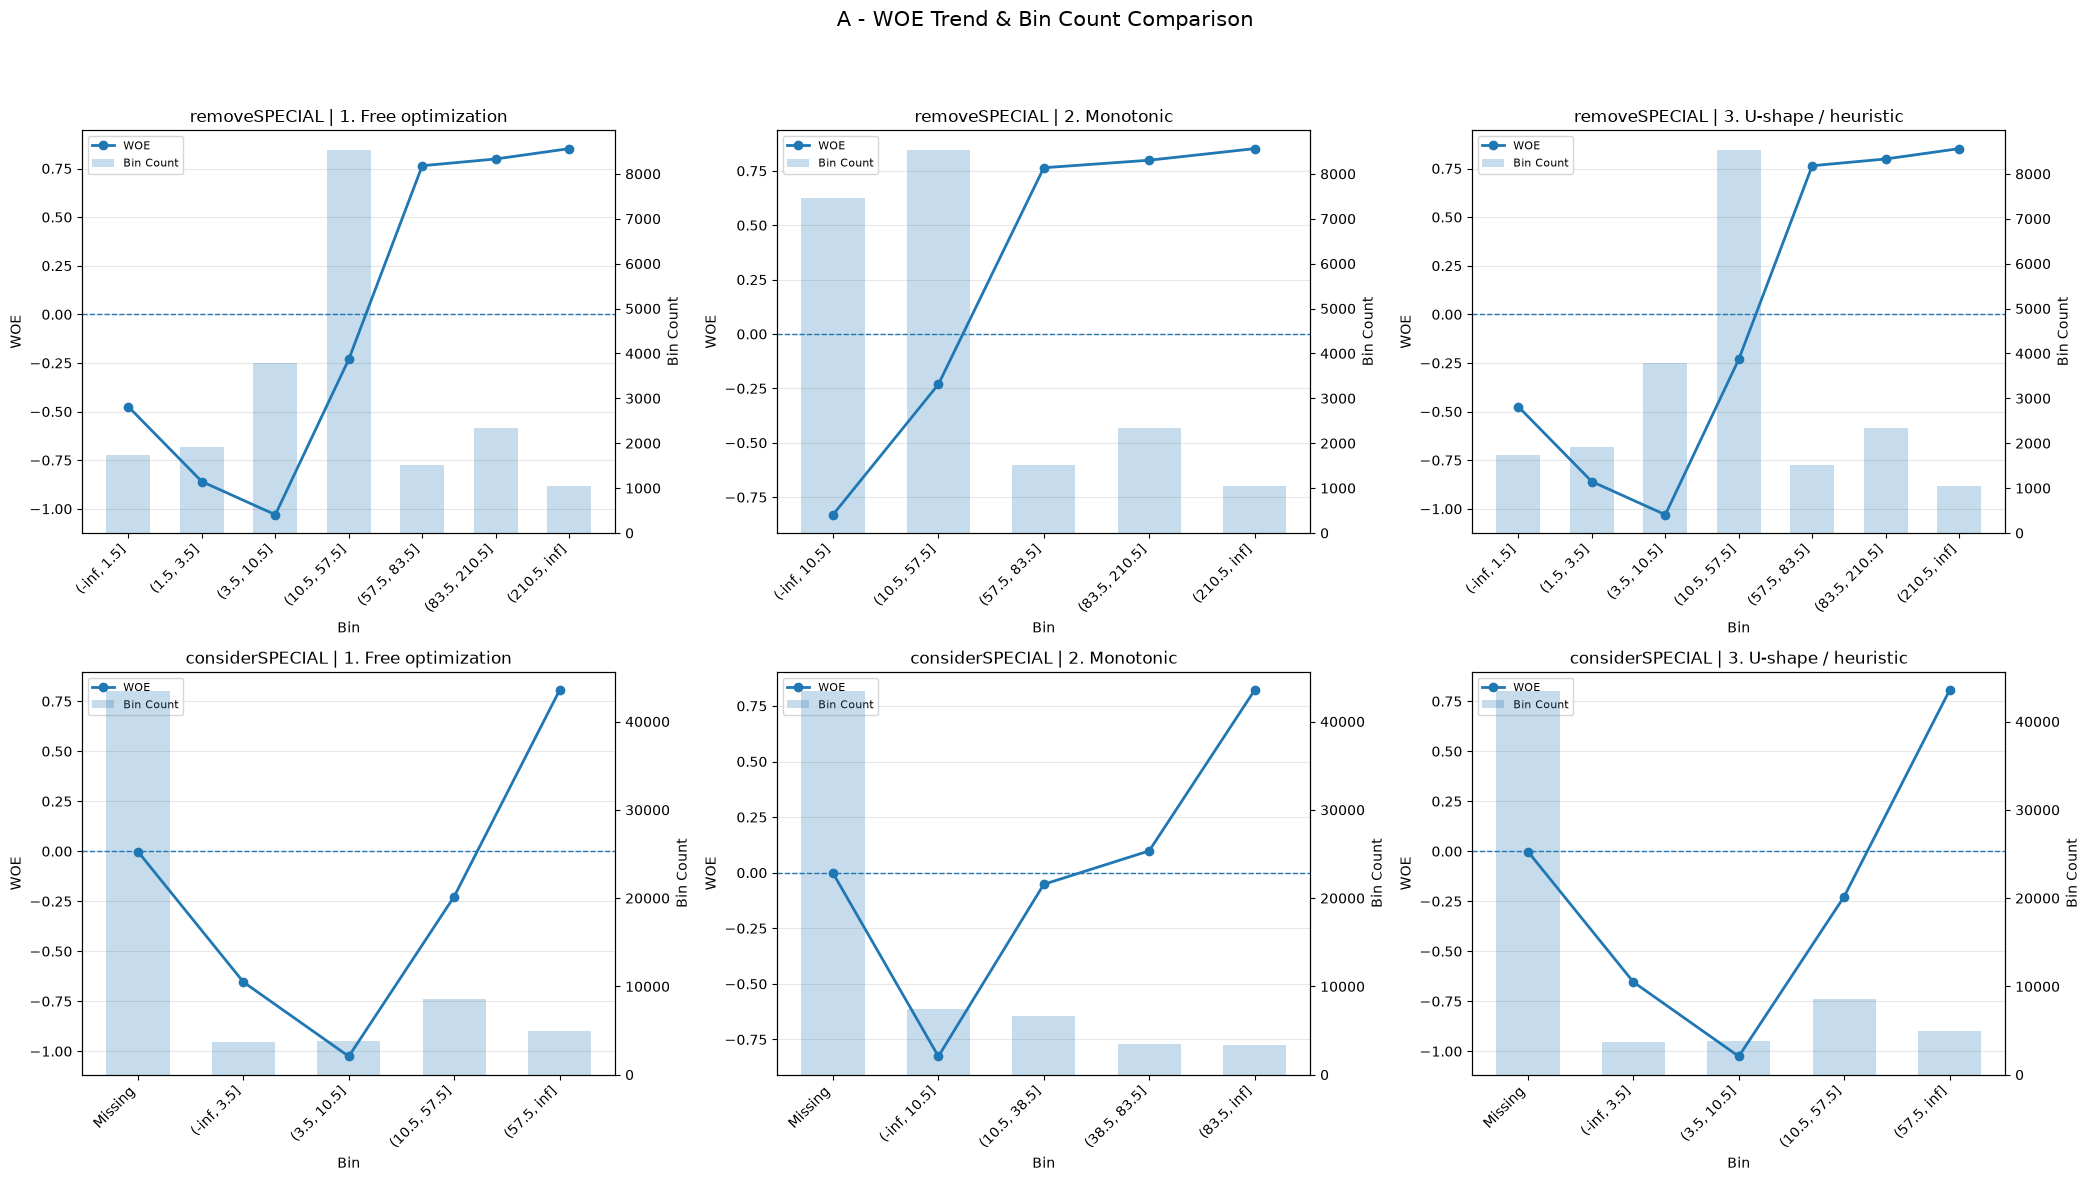

In [22]:
plot_options(results, feature)

### Bảng thông tin WOE và IV

In [23]:
woe_tables, html_code = display_woe_tables(
    results=results, create_woe_df_func=create_woe_df, render=False
)
grouped_html = display_grouped_woe_tables(html_code)
display(HTML(grouped_html))

WOE TABLES


Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,score
"(-inf, 1.5]",8.34%,5.19%,8.36%,-0.48,0.02,-0.0015
"(1.5, 3.5]",9.19%,3.90%,9.21%,-0.86,0.05,-0.0045
"(3.5, 10.5]",18.15%,6.49%,18.19%,-1.03,0.12,-0.0118
"(10.5, 57.5]",40.88%,32.47%,40.91%,-0.23,0.02,-0.0019
"(57.5, 83.5]",7.29%,15.58%,7.26%,0.76,0.06,0.0063
"(83.5, 210.5]",11.15%,24.68%,11.10%,0.80,0.11,0.0107
"(210.5, inf]",5.01%,11.69%,4.98%,0.85,0.06,0.0056


In [24]:
print('Các option đã tính:')
for option_name in woe_tables:
    print(' -', option_name)


Các option đã tính:
 - removeSPECIAL | 1. Free optimization
 - removeSPECIAL | 2. Monotonic
 - removeSPECIAL | 3. U-shape / heuristic
 - considerSPECIAL | 1. Free optimization
 - considerSPECIAL | 2. Monotonic
 - considerSPECIAL | 3. U-shape / heuristic


## Tùy chỉnh khoảng bin 
Comment/uncomment để chọn option

In [25]:
# chosen_option = 'removeSPECIAL | 1. Free optimization'
chosen_option = 'removeSPECIAL | 2. Monotonic'
# chosen_option = 'removeSPECIAL | 3. U-shape / heuristic'
# chosen_option = 'considerSPECIAL | 1. Free optimization'
# chosen_option = 'considerSPECIAL | 2. Monotonic'
# chosen_option = 'considerSPECIAL | 3. U-shape / heuristic'

result = results[chosen_option]
chosensplit = [float(s) for s in result['splits']]

display_x = result['x']
display_y = result['y']
missing_first = result['missing_first']
special = result['special']

if result['part'] == 'considerSPECIAL':
    min_bin_size = MIN_BIN_SIZE * n_old / n_new
    max_bin_size = min(MAX_BIN_SIZE * n_old / n_new, 1)
else:
    min_bin_size = MIN_BIN_SIZE
    max_bin_size = MAX_BIN_SIZE

print('Chosen option:', chosen_option)
print('Chosen splits:', chosensplit)
print('min_bin_size:', min_bin_size)
print('max_bin_size:', max_bin_size)
print('missing_first:', missing_first)
print('special:', special)


Chosen option: removeSPECIAL | 2. Monotonic
Chosen splits: [10.5, 57.5, 83.5, 210.5]
min_bin_size: 0.05
max_bin_size: 0.5
missing_first: False
special: []


Khoảng chia bin gốc được chọn

In [26]:
print(chosensplit)


[10.5, 57.5, 83.5, 210.5]


Copy bin gốc phía trên và Chỉnh sửa bin

In [27]:
edited_splits = [11, 58, 84, 210]

Kiểm tra bin mới có hợp lệ hay không? Nếu không thỏa điều kiện, sẽ raise lỗi

In [28]:
validation = validate_splits(
    x=x,
    splits=edited_splits,
    min_n_bins=MIN_BIN,
    max_n_bins=MAX_BIN,
    min_bin_size=min_bin_size,
    max_bin_size=max_bin_size,
)

print(f"Edited splits: {edited_splits}")
print(f"Number of bins: {validation.get('n_bins')}")

check_valid_bins(
    validation,
    min_bin_size=min_bin_size,
    max_bin_size=max_bin_size,
    min_n_bins=MIN_BIN,
    max_n_bins=MAX_BIN,
)

print("Result: Edited splits hợp lệ.")
splits = validation['splits']
print(f"Valid edited splits: {list(map(float, splits))}")


Edited splits: [11, 58, 84, 210]
Number of bins: 5
Result: Edited splits hợp lệ.
Valid edited splits: [11.0, 58.0, 84.0, 210.0]


### So sánh và đánh giá giữa bins gốc và mới

#### Kết quả gốc

In [29]:
old_woe_df = create_woe_df(display_x, display_y, chosensplit, missing_first=missing_first, special=special)
edited_woe_df = create_woe_df(display_x, display_y, splits, missing_first=missing_first, special=special)


#### Kết quả mới

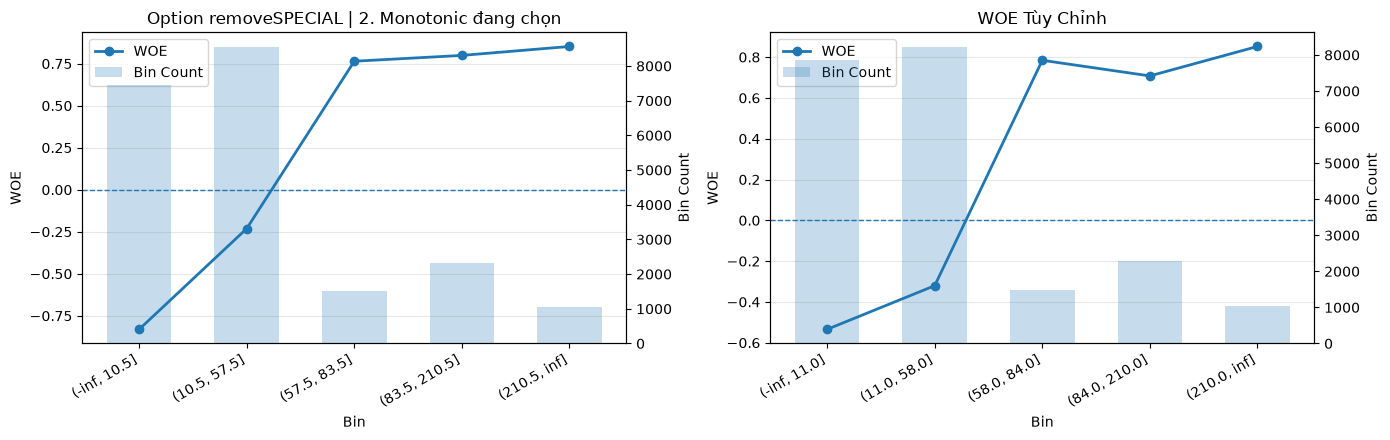

,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,"(-inf, 10.5]",35.68%,0.155844,0.357537,-0.8304,0.1675,0.4162
1,"(10.5, 57.5]",40.88%,0.324675,0.409067,-0.2311,0.0195,0.4162
2,"(57.5, 83.5]",7.29%,0.155844,0.072564,0.7644,0.0637,0.4162
3,"(83.5, 210.5]",11.15%,0.246753,0.110983,0.7990,0.1085,0.4162
4,"(210.5, inf]",5.01%,0.116883,0.049849,0.8522,0.0571,0.4162
,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,"(-inf, 11.0]",37.61%,0.220779,0.376699,-0.5343,0.0833,0.3207
1,"(11.0, 58.0]",39.32%,0.285714,0.393555,-0.3202,0.0345,0.3207
2,"(58.0, 84.0]",7.14%,0.155844,0.071123,0.7844,0.0665,0.3207
3,"(84.0, 210.0]",10.92%,0.220779,0.108774,0.7079,0.0793,0.3207


In [30]:
# Tạo 1 khung chung gồm 2 cột
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

plot_woe_onsplits(old_woe_df, display_x, display_y, chosensplit, feature=f'Option {chosen_option} đang chọn', missing_first=missing_first, special=special, ax=ax1)
plot_woe_onsplits(edited_woe_df, display_x, display_y, splits, feature='WOE Tùy Chỉnh', missing_first=missing_first, special=special, ax=ax2)

plt.tight_layout()
plt.show()
html1 = old_woe_df.style.format({'prob_n_obs': '{:.2%}', 'WOE': '{:.4f}', 'IV_detail': '{:.4f}', 'IV_total': '{:.4f}'}).to_html()
html2 = edited_woe_df.style.format({'prob_n_obs': '{:.2%}', 'WOE': '{:.4f}', 'IV_detail': '{:.4f}', 'IV_total': '{:.4f}'}).to_html()

display(HTML(f'''<div style="display: flex; gap: 20px; align-items: flex-start;"><div style="flex: 1;"><p>Kết quả option {chosen_option} đang chọn</p>{html1}</div><div style="flex: 1;"><p>Kết quả WOE tùy chỉnh</p>{html2}</div></div>'''))


#### Chênh lệch IV tổng

In [31]:
comparison = compare_woe_tables(old_woe_df, edited_woe_df)
iv = comparison['iv_total']
comment_iv_total(iv)


IV total gốc : 0.416247
IV total mới : 0.320711
IV total mới GIẢM 0.095537 so với cũ.


#### Kiểm tra lại xu hướng WOE

In [32]:
trend = comparison['woe_trend']
comment_woe_trend(trend)


WOE trend gốc : monotonic
WOE trend mới : no_clear_trend
WOE trend thay đổi: monotonic -> no_clear_trend.


#### Khác biệt theo từng bin theo cách chia gốc và cách chia mới

In [33]:
comparison['iv_bin_comparison']

,bin_order,Bin_old,Bin_new,IV_old,IV_new,gap
0,1,"(-inf, 10.5]","(-inf, 11.0]",0.167483,0.083305,-0.084177
1,2,"(10.5, 57.5]","(11.0, 58.0]",0.019499,0.034534,0.015035
2,3,"(57.5, 83.5]","(58.0, 84.0]",0.063658,0.066459,0.002800
3,4,"(83.5, 210.5]","(84.0, 210.0]",0.108482,0.079288,-0.029194
4,5,"(210.5, inf]","(210.0, inf]",0.057125,0.057125,0.000000


Những bin thay đổi qua các mức xác định (0.02, 0.1, 0.3, 0.5).

In [34]:
display_threshold_changes(comparison)

,bin_order,Bin_old,Bin_new,IV_old,IV_new,gap,threshold_old,threshold_new,threshold_changed
0,1,"(-inf, 10.5]","(-inf, 11.0]",0.1675,0.0833,-0.0842,"[0.10, 0.30)","[0.02, 0.10)",True
1,2,"(10.5, 57.5]","(11.0, 58.0]",0.0195,0.0345,+0.0150,< 0.02,"[0.02, 0.10)",True
2,3,"(57.5, 83.5]","(58.0, 84.0]",0.0637,0.0665,+0.0028,"[0.02, 0.10)","[0.02, 0.10)",False
3,4,"(83.5, 210.5]","(84.0, 210.0]",0.1085,0.0793,-0.0292,"[0.10, 0.30)","[0.02, 0.10)",True
4,5,"(210.5, inf]","(210.0, inf]",0.0571,0.0571,+0.0000,"[0.02, 0.10)","[0.02, 0.10)",False
